In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")
sns.set_context("paper", font_scale=1.0)
plt.rcParams["font.family"] = "serif"

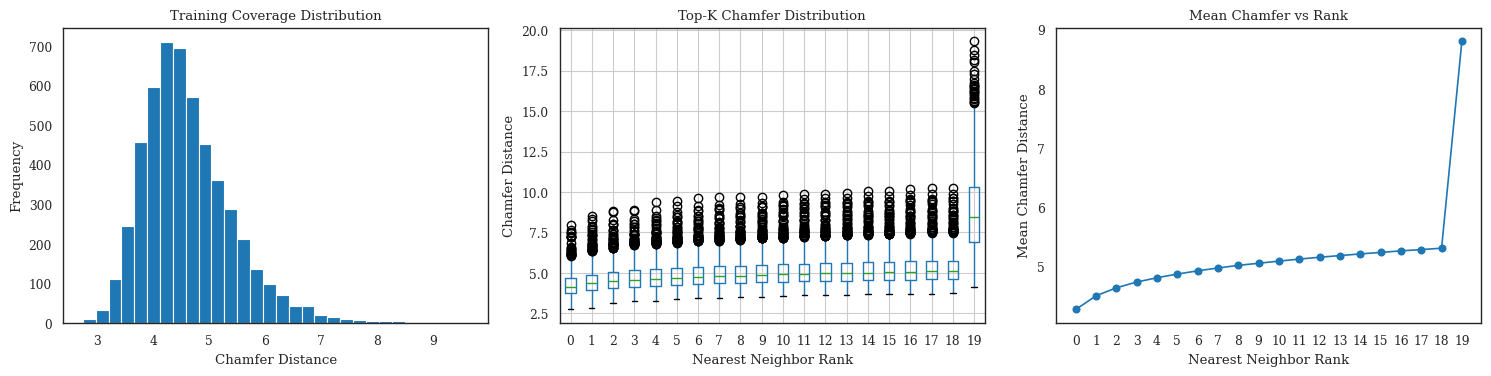

In [6]:
# Load data
train_cov = pd.read_csv("/storage/code/VQ_diffusion/evaluation/chamfer/training_min_covered_by_generated.csv")
topk = pd.read_csv("/storage/code/VQ_diffusion/evaluation/chamfer/topk_per_generated.csv")

# Prepare mean per rank
mean_by_rank = topk.groupby("rank")["chamfer"].mean()

# Create figure with 1x3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# -------------------------
# (1) Histogram
# -------------------------
axes[0].hist(train_cov["chamfer_min"], bins=30)
axes[0].set_xlabel("Chamfer Distance")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Training Coverage Distribution")

# -------------------------
# (2) Boxplot (Top-K)
# -------------------------
topk.boxplot(column="chamfer", by="rank", ax=axes[1])
axes[1].set_xlabel("Nearest Neighbor Rank")
axes[1].set_ylabel("Chamfer Distance")
axes[1].set_title("Top-K Chamfer Distribution")

# Remove automatic pandas title
axes[1].figure.suptitle("")

# -------------------------
# (3) Mean vs Rank
# -------------------------
axes[2].plot(mean_by_rank.index, mean_by_rank.values, marker="o")
axes[2].set_xlabel("Nearest Neighbor Rank")
axes[2].set_ylabel("Mean Chamfer Distance")
axes[2].set_title("Mean Chamfer vs Rank")
axes[2].set_xticks(range(20))

# -------------------------
# Layout & save
# -------------------------
plt.tight_layout()
plt.savefig("chamfer_1x3_figure.pdf", bbox_inches="tight")
plt.savefig("chamfer_1x3_figure.png", dpi=300, bbox_inches="tight")
plt.show()